# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [108]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress
from pathlib import Path

# Impor the OpenWeatherMap API key
from config import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [109]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name
    
    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 588


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [110]:
# Set the API base URL.
url = "https://api.openweathermap.org/data/2.5/weather"

# Define an empty list for the weather data.
city_data = []

# Print to logger.
print("Beginning Data Retrieval")
print("-----------------------------")

# Create counters.
record_count = 1
set_count = 1

# Loop through the cities and retrieve weather data.
for i, city in enumerate(cities):

    # Group cities into sets of 50 for logging.
    if i % 50 == 0 and i >= 50:
        set_count += 1
        record_count = 1

    print(
        f"Processing Record {record_count} "
        f"of Set {set_count} | {city}"
    )

    record_count += 1

    params = {
        "q": city,
        "appid": weather_api_key,
        "units": "imperial",
    }

    try:
        response = requests.get(
            url,
            params=params,
            timeout=10,
        )
        response.raise_for_status()
        city_weather = response.json()

        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        city_data.append({
            "City": city,
            "Lat": city_lat,
            "Lng": city_lng,
            "Max Temp": city_max_temp,
            "Humidity": city_humidity,
            "Cloudiness": city_clouds,
            "Wind Speed": city_wind,
            "Country": city_country,
            "Date": city_date,
        })

    except (requests.RequestException, KeyError, TypeError):
        print("City not found or request failed. Skipping...")

    # Pause to avoid exceeding the API rate limit.
    time.sleep(1)

# Indicate that data loading is complete.
print("-----------------------------")
print("Data Retrieval Complete")
print("-----------------------------")

Beginning Data Retrieval
-----------------------------
Processing Record 1 of Set 1 | papatowai
Processing Record 2 of Set 1 | karasburg
Processing Record 3 of Set 1 | puerto san carlos
City not found or request failed. Skipping...
Processing Record 4 of Set 1 | port-aux-francais
Processing Record 5 of Set 1 | olonkinbyen
Processing Record 6 of Set 1 | ushuaia
Processing Record 7 of Set 1 | port mathurin
Processing Record 8 of Set 1 | ribeira grande
Processing Record 9 of Set 1 | hitzacker
Processing Record 10 of Set 1 | dunedin
Processing Record 11 of Set 1 | aasiaat
Processing Record 12 of Set 1 | college
Processing Record 13 of Set 1 | revda
Processing Record 14 of Set 1 | mukalla
Processing Record 15 of Set 1 | twon-brass
Processing Record 16 of Set 1 | valparaiso
Processing Record 17 of Set 1 | yellowknife
Processing Record 18 of Set 1 | west island
Processing Record 19 of Set 1 | lompoc
Processing Record 20 of Set 1 | tiksi
Processing Record 21 of Set 1 | grytviken
Processing Rec

In [111]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          566
Lat           566
Lng           566
Max Temp      566
Humidity      566
Cloudiness    566
Wind Speed    566
Country       566
Date          566
dtype: int64

In [112]:
# Display sample data
city_data_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,papatowai,-46.5619,169.4708,51.69,69,29,12.26,NZ,1787104408
1,karasburg,-28.0167,18.7500,62.64,17,0,6.11,NA,1787104409
2,port-aux-francais,-49.3500,70.2167,31.93,93,100,19.28,TF,1787104413
3,olonkinbyen,70.9221,-8.7187,41.07,82,100,10.56,SJ,1787104414
4,ushuaia,-54.8000,-68.3000,38.86,81,94,21.85,AR,1787104416
5,port mathurin,-19.6833,63.4167,71.69,78,30,17.27,MU,1787104417
6,ribeira grande,38.5167,-28.7000,74.77,88,3,7.00,PT,1787104419
7,hitzacker,53.1525,11.0442,62.40,92,100,9.28,DE,1787104420
8,dunedin,-45.8742,170.5036,53.62,70,50,11.01,NZ,1787104314
9,aasiaat,68.7098,-52.8699,38.52,98,100,5.39,GL,1787104423


In [113]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [114]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,papatowai,-46.5619,169.4708,51.69,69,29,12.26,NZ,1787104408
1,karasburg,-28.0167,18.7500,62.64,17,0,6.11,NaN,1787104409
2,port-aux-francais,-49.3500,70.2167,31.93,93,100,19.28,TF,1787104413
3,olonkinbyen,70.9221,-8.7187,41.07,82,100,10.56,SJ,1787104414
4,ushuaia,-54.8000,-68.3000,38.86,81,94,21.85,AR,1787104416


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

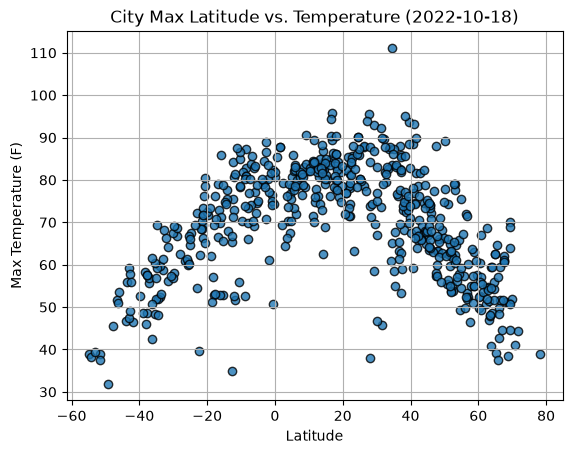

In [115]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (F)")
plt.title("City Max Latitude vs. Temperature (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

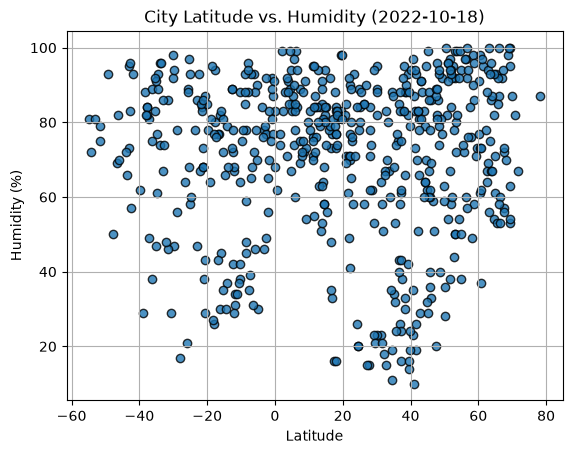

In [116]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.title("City Latitude vs. Humidity (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

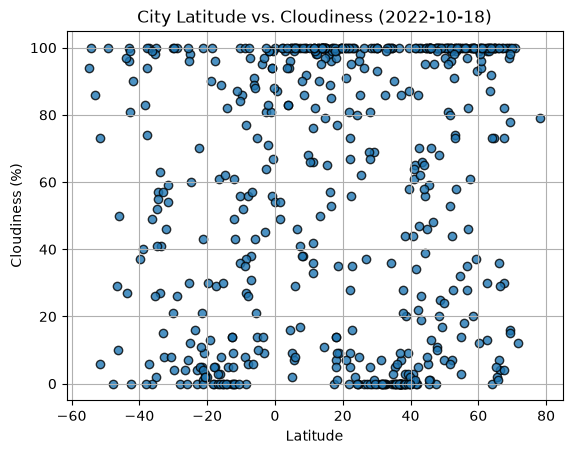

In [117]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.title("City Latitude vs. Cloudiness (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

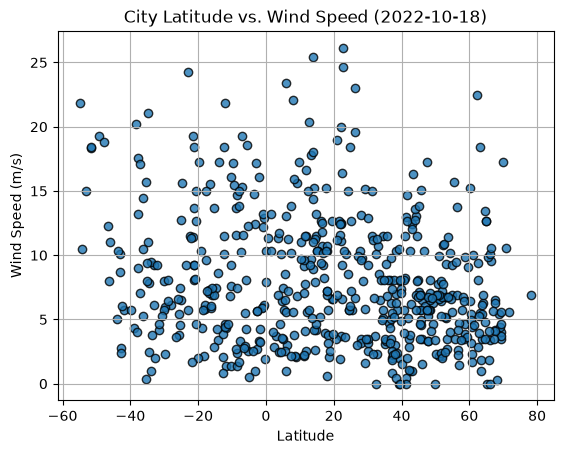

In [118]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.title("City Latitude vs. Wind Speed (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [119]:
def create_linear_regression_plot(
        dataframe,
        x_column,
        y_column,
        title,
        y_label,
        output_filename,
):
    """Create, display, and save a scatterplot with linear regression."""
    clean_data = dataframe[[x_column, y_column]].dropna()

    x_values = clean_data[x_column]
    y_values = clean_data[y_column]

    slope, intercept, r_value, p_value, std_err = linregress(
        x_values,
        y_values,
    )

    regression_x = np.linspace(
        x_values.min(),
        x_values.max(),
        100,
    )
    regression_y = slope * regression_x + intercept

    equation = f"y = {slope:.2f}x + {intercept:.2f}"
    r_squared = r_value ** 2

    print(f"The r² value is: {r_squared:.4f}")

    figure, axis = plt.subplots(figsize=(8, 5))

    axis.scatter(
        x_values,
        y_values,
        edgecolors="black",
        alpha=0.80,
    )

    axis.plot(
        regression_x,
        regression_y,
        color="red",
    )

    axis.set_title(title)
    axis.set_xlabel("Latitude")
    axis.set_ylabel(y_label)
    axis.grid(True)

    axis.text(
        0.05,
        0.95,
        f"{equation}\nR² = {r_squared:.2f}",
        transform=axis.transAxes,
        fontsize=12,
        color="red",
        verticalalignment="top",
    )

    output_path = Path("output_data") / output_filename
    figure.savefig(output_path, bbox_inches="tight")

    plt.show()

    return slope, intercept, r_squared

In [120]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >= 0]

# Display sample data
northern_hemi_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
3,olonkinbyen,70.9221,-8.7187,41.07,82,100,10.56,SJ,1787104414
6,ribeira grande,38.5167,-28.7000,74.77,88,3,7.00,PT,1787104419
7,hitzacker,53.1525,11.0442,62.40,92,100,9.28,DE,1787104420
9,aasiaat,68.7098,-52.8699,38.52,98,100,5.39,GL,1787104423
10,college,64.8569,-147.8028,62.55,71,100,12.66,US,1787104425
11,revda,56.8010,59.9303,53.37,92,28,2.66,RU,1787104426
12,mukalla,14.5425,49.1242,82.72,68,11,2.66,YE,1787104428
13,twon-brass,4.3151,6.2418,76.68,89,96,10.11,NG,1787104429
15,yellowknife,62.4560,-114.3525,68.56,64,13,8.05,CA,1787104309


In [121]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df["Lat"] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,papatowai,-46.5619,169.4708,51.69,69,29,12.26,NZ,1787104408
1,karasburg,-28.0167,18.7500,62.64,17,0,6.11,NaN,1787104409
2,port-aux-francais,-49.3500,70.2167,31.93,93,100,19.28,TF,1787104413
4,ushuaia,-54.8000,-68.3000,38.86,81,94,21.85,AR,1787104416
5,port mathurin,-19.6833,63.4167,71.69,78,30,17.27,MU,1787104417


###  Temperature vs. Latitude Linear Regression Plot

The r² value is: 0.4891


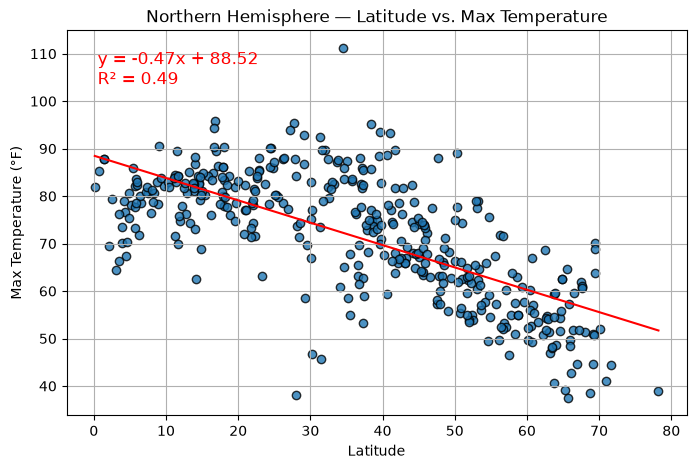

(np.float64(-0.4708492967079593),
 np.float64(88.52338552127466),
 np.float64(0.4891108301834433))

In [122]:
create_linear_regression_plot(
    northern_hemi_df,
    "Lat",
    "Max Temp",
    "Northern Hemisphere — Latitude vs. Max Temperature",
    "Max Temperature (°F)",
    "northern_temp_regression.png",
)

The r² value is: 0.5718


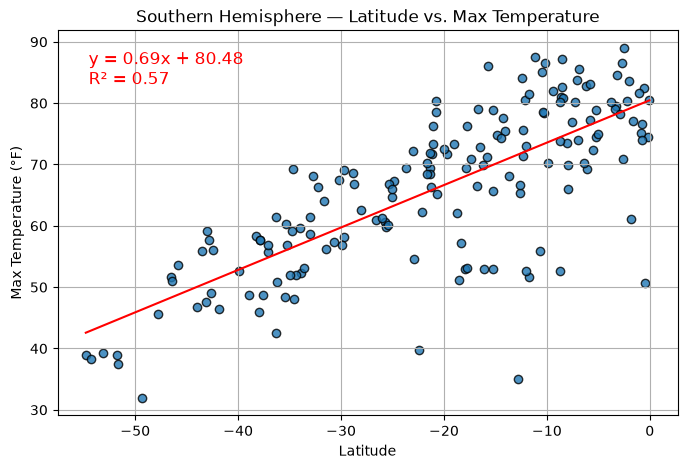

(np.float64(0.6916974883171753),
 np.float64(80.47828235054976),
 np.float64(0.5718444832177901))

In [123]:
create_linear_regression_plot(
    southern_hemi_df,
    "Lat",
    "Max Temp",
    "Southern Hemisphere — Latitude vs. Max Temperature",
    "Max Temperature (°F)",
    "southern_temp_regression.png",
)

### Humidity vs. Latitude Linear Regression Plot

The r^2 value is: {r_value**2}


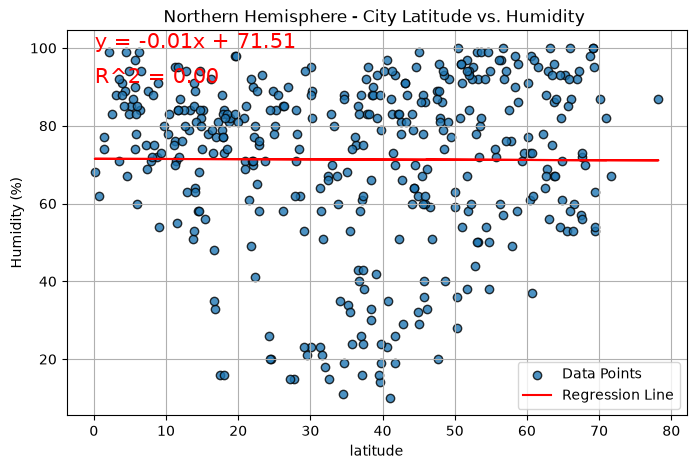

In [124]:
# Northern Hemisphere
city_data_df = pd.DataFrame(city_data)

#Create a DataFrame with the Northern Hemisphere data (Latitude >=0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >=0]

#Extract the variables 
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

#Perform linear regression 
slope, intercept, r_value, p_value, std_err, = linregress(x_values, y_values)

#Create regression line values 
regress_values = x_values * slope + intercept
line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

#Output the R-squared value
print("The r^2 value is: {r_value**2}")

#Build the scatter plot 
plt.figure(figsize=(8,5))
plt.scatter(x_values, y_values, edgecolors="black", alpha=0.80, label="Data Points")

#Plot the regression line
plt.plot(x_values,regress_values, "r-", label="Regression Line")

#Incorporate the other graph properties 
plt.xlabel("latitude")
plt.ylabel("Humidity (%)")
plt.title("Northern Hemisphere - City Latitude vs. Humidity ")
plt.grid(True)

#Add line equation and r-squared value to the plot 
plt.annotate(line_eq, (min(x_values), max(y_values)), fontsize=15, color="red")
plt.annotate(f"R^2 = {r_value**2:.2f}", (min(x_values), max(y_values) - (max(y_values) - min(y_values)) * 0.1), fontsize=15, color="red")

#Add legend 
plt.legend()

#Save the figure
plt.savefig("Lat_vs_Humidity.png")

#Show plot
plt.show()

In [125]:
# Southern Hemisphere
# YOUR CODE HERE

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Cloudiness vs. Latitude Linear Regression Plot

In [126]:
# Northern Hemisphere
# YOUR CODE HERE

In [127]:
# Southern Hemisphere
# YOUR CODE HERE

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Wind Speed vs. Latitude Linear Regression Plot

In [128]:
# Northern Hemisphere
# YOUR CODE HERE

In [129]:
# Southern Hemisphere
# YOUR CODE HERE

**Discussion about the linear relationship:** YOUR RESPONSE HERE